# CÍL 6: ÚKOL – Segmentace medicínských snímků

> Tento notebook je součástí cvičení 12 předmětu BPC-PRG.  
> 📥 **[Stáhnout notebook (cviceni_12_segmentace.ipynb)](cviceni_12_segmentace.ipynb)** &nbsp;|&nbsp; 📥 **[Stáhnout data (cviceni_12_segmentace_data.zip)](../cviceni_12_segmentace_data.zip)**
>
> Po stažení ZIP rozbal vedle notebooku — vzniknou složky `skupina_a/` a `skupina_b/` se snímky.


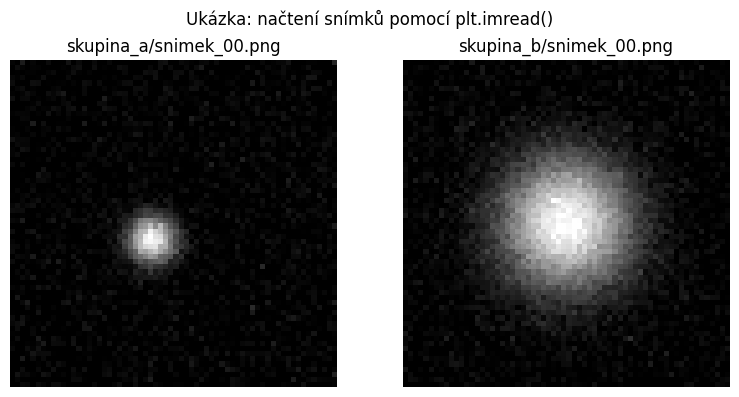

Tvar pole: (64, 64), hodnoty: min=0.000, max=1.000


In [1]:
# Ukázkové načtení a zobrazení dvou snímků pomocí pevně zadané cesty
# Spuštěním této buňky ověříš, že jsou soubory dostupné a funkce plt.imread() funguje
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

snimek_a = plt.imread("skupina_a/snimek_00.png")[:, :, 0]
snimek_b = plt.imread("skupina_b/snimek_00.png")[:, :, 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(snimek_a, cmap="gray", vmin=0, vmax=1)
ax1.set_title("skupina_a/snimek_00.png")
ax1.axis("off")
ax2.imshow(snimek_b, cmap="gray", vmin=0, vmax=1)
ax2.set_title("skupina_b/snimek_00.png")
ax2.axis("off")
plt.suptitle("Ukázka: načtení snímků pomocí plt.imread()")
plt.tight_layout()
plt.show()
print(f"Tvar pole: {snimek_a.shape}, hodnoty: min={snimek_a.min():.3f}, max={snimek_a.max():.3f}")


## Zadání

Máš k dispozici dvě skupiny simulovaných medicínských snímků ve složkách
`skupina_a/` a `skupina_b/` (5 snímků `.png` v každé složce):

- **`skupina_a/`** – „Zdravá tkáň": malý, kompaktní jasný region (~20 % plochy)
- **`skupina_b/`** – „Nádorová tkáň": velký, rozlitý jasný region (~45 % plochy)

Snímky načteš pomocí `plt.imread()`. Ten vrátí RGBA pole tvaru `(64, 64, 4)` –
pro práci s intenzitou stačí vzít první kanál: `snimek = plt.imread(...)[:, :, 0]`

Proveď postupně tyto kroky:

1. **Načti data** – načti všechny snímky ze složek a zobraz první snímek z každé skupiny.
2. **Prahování** – naprahuj jeden snímek, vytvoř binární masku a zobraz ji vedle originálu.
3. **Kvantitativní analýza** – spočítej poměrnou plochu pokrytou strukturou a průměrnou intenzitu uvnitř masky.
4. **Srovnání skupin** – zpracuj všechny snímky obou skupin a porovnej poměrné plochy boxplotem.


### Krok 1 – Načtení všech snímků

**Cíl:** Načíst všechny PNG snímky z obou složek do paměti jako NumPy pole a podívat se, jak vypadají.

**Jak na to:**

- Získej seznamy souborů ze složek: `sorted(glob.glob("skupina_a/*.png"))`.
- Každý snímek načti přes `plt.imread()`. Funkce vrátí RGBA pole tvaru `(64, 64, 4)` — bereme jen první kanál
  (intenzita): `plt.imread(cesta)[:, :, 0]`.
- Ulož obrázky do dvou seznamů `skupina_a` a `skupina_b`.

**Jak vizualizovat:**

- Pomocí `plt.subplots(1, 2)` zobraz první snímek každé skupiny vedle sebe.
- Na obou použij `ax.imshow(..., cmap="gray", vmin=0, vmax=1)` a popisný titulek (např. „Zdravá tkáň – snímek 0").
- `ax.axis("off")` skryje souřadnice, aby byl obrázek hezčí.

Načteno snímků skupiny A: 5
Načteno snímků skupiny B: 5


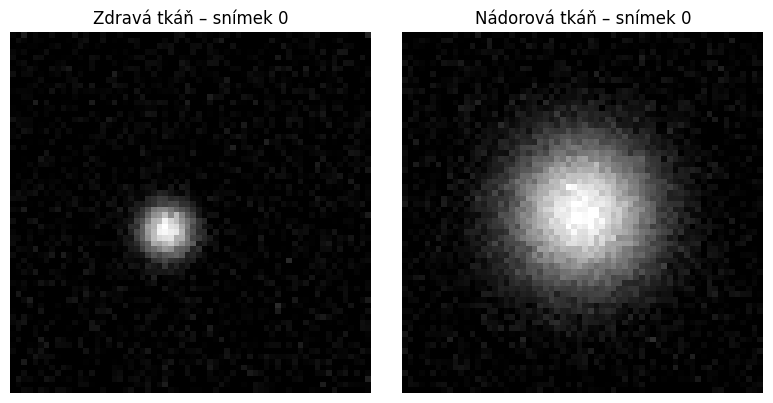

In [5]:
%matplotlib inline
import glob
import numpy as np
import matplotlib.pyplot as plt

# 1) Získej seznamy souborů přes glob.glob() (nezapomeň na sorted())
files_a = sorted(glob.glob("skupina_a/*.png"))
files_b = sorted(glob.glob("skupina_b/*.png"))

# 2) Načti obrázky — pro každý soubor: plt.imread(cesta)[:, :, 0]
skupina_a = [plt.imread(f)[:, :, 0] for f in files_a]
skupina_b = [plt.imread(f)[:, :, 0] for f in files_b]

print(f"Načteno snímků skupiny A: {len(skupina_a)}")
print(f"Načteno snímků skupiny B: {len(skupina_b)}")

# 3) Zobraz první snímek z každé skupiny vedle sebe
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.imshow(skupina_a[0], cmap="gray", vmin=0, vmax=1)
ax1.set_title("Zdravá tkáň – snímek 0")
ax1.axis("off")

ax2.imshow(skupina_b[0], cmap="gray", vmin=0, vmax=1)
ax2.set_title("Nádorová tkáň – snímek 0")
ax2.axis("off")

plt.tight_layout()
plt.show()

### Krok 2 – Prahování a vizualizace masky

**Cíl:** Pro jeden snímek vytvořit **binární masku** — pole typu `bool`, kde `True` znamená „tento pixel patří
do struktury".

**Jak na to:**

- Zvol práh, např. `PRAH = 0.5`. Pixely s intenzitou nad tuto hodnotu označíme jako součást struktury.
- Vyber jeden snímek (třeba `snimek = skupina_a[0]`).
- Masku vytvoříš jediným výrazem: `maska = snimek > PRAH` — NumPy vrátí pole `True`/`False` stejného tvaru.

**Jak vizualizovat:**

- Zobraz dva grafy vedle sebe:
    - **levý** – původní snímek s `cmap="gray"` a `vmin=0, vmax=1`,
    - **pravý** – binární maska s `cmap="gray"` (bílá/černá).
- Do titulku pravého grafu dej použitý práh, ať je hned vidět s jakým parametrem experimentuješ.

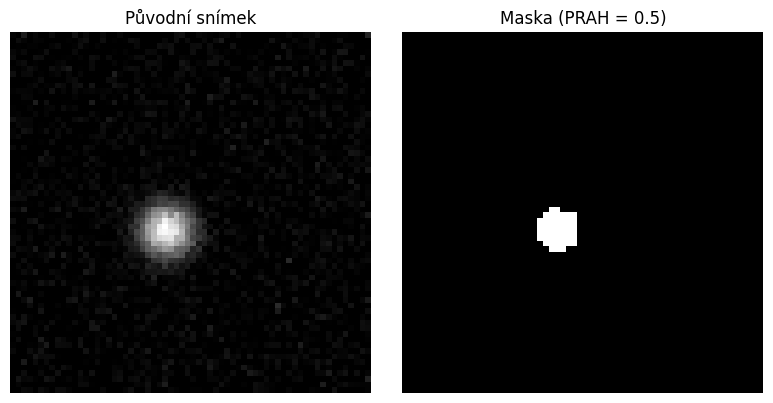

In [6]:
PRAH = 0.5
snimek = skupina_a[0]

# 1) Vytvoř binární masku pomocí porovnání snimek > PRAH
maska = snimek > PRAH

# 2) Vykresli snímek a masku vedle sebe (subplots(1, 2))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.imshow(snimek, cmap="gray", vmin=0, vmax=1)
ax1.set_title("Původní snímek")
ax1.axis("off")

ax2.imshow(maska, cmap="gray")
ax2.set_title(f"Maska (PRAH = {PRAH})")
ax2.axis("off")

plt.tight_layout()
plt.show()

### Krok 3 – Kvantitativní analýza

**Cíl:** Pro snímek + masku z Kroku 2 spočítat dvě čísla:

1. **Poměrná plocha struktury** (v %) — jaký podíl obrazu tvoří pixely nad prahem.
2. **Průměrná intenzita** uvnitř struktury — průměr pixelů, pro které je maska `True`.

**Jak na to:**

- `maska.sum()` — NumPy sečte `True` (každé bere jako 1) → **počet pixelů ve struktuře**.
- `maska.size` — celkový počet pixelů v obraze (pro 64×64 je to 4096).
- `snimek[maska]` — NumPy boolean indexing: vrátí 1D pole s hodnotami tam, kde je maska `True`.

**Jak vizualizovat:** tady stačí `print()`. Čísla hrají roli, graf ne.

In [11]:
# 1) Poměrná plocha struktury v % (maska.sum() z celkového maska.size)
podil = (maska.sum() / maska.size) * 100

# 2) Průměrná intenzita pixelů uvnitř masky
mean_int = snimek[maska].mean()

print(f"Plocha struktury: {podil:.1f} %")
print(f"Průměrná intenzita: {mean_int:.3f}")

Plocha struktury: 1.1 %
Průměrná intenzita: 0.714


### Krok 4 – Srovnání skupin: boxplot

**Cíl:** Aplikovat stejné prahování na **všech 10 snímků** (5 v každé skupině), získat pro každý poměrnou
plochu a výsledky porovnat boxplotem.

**Jak na to:**

- Pro každou skupinu projdi všechny snímky a spočítej poměrnou plochu při `PRAH = 0.5`.
- Výsledky ulož do dvou seznamů: `podily_a`, `podily_b`.
- Je fajn si definovat malou funkci `spocitej_podil(snimek, prah)` — ať se neopakuješ.

**Jak vizualizovat:**

- `ax.boxplot([podily_a, podily_b], tick_labels=["Zdravá tkáň", "Nádorová tkáň"])`.
- Popiš osu Y (`"Plocha struktury (%)"`), přidej titulek.
- `ax.grid(True, axis="y", alpha=0.4)` zlepší čitelnost mřížky.

**Co bys měl vidět:** „nádorová" skupina má výrazně větší plochu pokrytou strukturou (~45 %) než skupina
zdravá (~20 %) — boxy by měly být zřetelně oddělené.

Skupina A (zdravá tkáň): ['1.1 %', '1.1 %', '1.1 %', '1.1 %', '1.1 %']
Skupina B (nádorová tkáň): ['8.1 %', '8.3 %', '8.3 %', '7.9 %', '8.2 %']


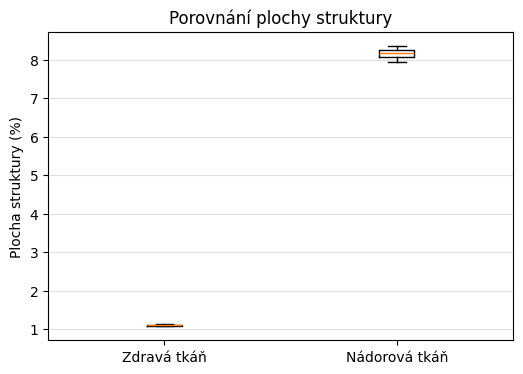

In [9]:
PRAH = 0.5
def spocitaj_podil(snimek, prah):
    maska = snimek > prah
    return (maska.sum() / maska.size) * 100
# 1) Pro každý snímek v obou skupinách spočítej poměrnou plochu (v %)
podily_a = [spocitaj_podil(s, PRAH) for s in skupina_a]
podily_b = [spocitaj_podil(s, PRAH) for s in skupina_b]

# 2) Vykresli boxplot obou skupin vedle sebe
fig, ax = plt.subplots(figsize=(6, 4))

ax.boxplot([podily_a, podily_b],
           tick_labels=["Zdravá tkáň", "Nádorová tkáň"])

ax.set_ylabel("Plocha struktury (%)")
ax.set_title("Porovnanie")
ax.grid(True, axis="y", alpha=0.4)
print("Skupina A (zdravá tkáň):", [f"{p:.1f} %" for p in podily_a])
print("Skupina B (nádorová tkáň):", [f"{p:.1f} %" for p in podily_b])

### Interpretace

Krátce komentuj:

- Jak se skupiny liší v poměrné ploše struktury?
- Dá se rozdíl pozorovat pouhým okem i z původních snímků (Krok 1), nebo je potřeba kvantitativní analýzy?
- Co by v reálné situaci mohlo narušit tuto jednoduchou metodu (např. šum, různá intenzita osvětlení,
  artefakty)? Jak by se dalo postupovat dál?

*Sem napiš svou odpověď.*

Vyzerá to tak, že nádorové obrázky majú viac svetlých pixelov (asi 45 %), kým zdravé ich majú menej (asi 20 %). Čiže v nádorovej skupine je tej štruktúry jednoducho viac.

Trochu áno – na nádorových obrázkoch je viac svetlej oblasti, ale nie je to úplne presné na pohľad. Preto je lepšie použiť výpočet, ktorý dá konkrétne číslo.


Môže to skresliť napríklad šum (bodky v obrázku), iné osvetlenie alebo nepresnosti v snímkach. V praxi by sa to riešilo tak, že by sa obrázky najprv vyčistili (filtrovanie) alebo by sa použila lepšia metóda než len jednoduché prahovanie.
